# CrisisGrid — Real GRPO Training
**Do NOT run in CPU mode.** `Runtime → Change runtime type → T4 GPU`

Architecture: ONE FULL EPISODE = ONE TRAINING SAMPLE
Baseline to beat: **30.8%** | Target: 45–65%

In [1]:
# CELL 1: Verify GPU
import torch
assert torch.cuda.is_available(), 'NO GPU. Change runtime to T4 and re-run.'
print(f'GPU ready: {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

GPU ready: Tesla T4
VRAM: 15.6 GB


In [2]:
# CELL 2: Install dependencies
!pip install -q unsloth trl transformers accelerate bitsandbytes wandb datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/

In [3]:
# CELL 3: Mount Drive + Set Paths
from google.colab import drive
drive.mount('/content/drive')

import sys, os

PROJECT_PATH = '/content/drive/MyDrive/CrisisGrid_System'
CKPT_DIR     = '/content/drive/MyDrive/crisisgrid_checkpoints'

sys.path.insert(0, PROJECT_PATH)
os.makedirs(CKPT_DIR, exist_ok=True)
print('Project path:', PROJECT_PATH)
print('Checkpoint dir:', CKPT_DIR)

Mounted at /content/drive
Project path: /content/drive/MyDrive/CrisisGrid_System
Checkpoint dir: /content/drive/MyDrive/crisisgrid_checkpoints


In [4]:
# CELL 3b: STEP 0 — Create project folder structure in Drive
# Run this BEFORE uploading files. Safe to re-run.
for sub in ['environment', 'training', 'utils', 'data']:
    os.makedirs(f'{PROJECT_PATH}/{sub}', exist_ok=True)
print('Project folders created at:', PROJECT_PATH)
print('Now upload your local files into each subfolder via the Drive UI.')
print('Do NOT upload: simulate scripts, logs, notebooks, doc files, __pycache__')

Project folders created at: /content/drive/MyDrive/CrisisGrid_System
Now upload your local files into each subfolder via the Drive UI.
Do NOT upload: simulate scripts, logs, notebooks, doc files, __pycache__


In [5]:
# CELL 4: Verify Environment — STOP IF THIS FAILS
from environment.crisis_grid_env import CrisisGridEnv
import numpy as np

env = CrisisGridEnv(seed=42)
obs_cmd, obs_res = env.reset()
assert isinstance(obs_cmd, dict), 'obs_cmd must be a dict'
assert 'grid' in obs_cmd, 'obs_cmd must contain grid key'

rng = np.random.RandomState(0)
for _ in range(3):
    msg = {'intent':'allocate','zone':int(rng.randint(0,25)),
           'resource':'medicine','priority':'high','units':5}
    obs_cmd, r, done, info = env.step(msg)

print(f'Environment OK — survival_rate: {info["survival_rate"]:.1%}')
print(f'Schema version: {obs_cmd.get("current_schema_version")}')

Environment OK — survival_rate: 98.5%
Schema version: 1


In [6]:
# CELL 5: WandB Login
import wandb
wandb.login()  # Paste your API key when prompted
print('WandB authenticated')

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kaviyathamizhan37 (kaviyathamizhan37-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


WandB authenticated


In [7]:
# CELL 6: Load Model (Qwen 1.5B 4-bit via Unsloth)
from unsloth import FastLanguageModel

MODEL_NAME = 'unsloth/Qwen2-1.5B-Instruct-bnb-4bit'

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=2048,
    load_in_4bit=True,
    dtype=None,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    lora_alpha=16,
    target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj',
                    'gate_proj', 'up_proj', 'down_proj'],
    lora_dropout=0,
    bias='none',
    use_gradient_checkpointing='unsloth',
)
print(f'Model loaded: {MODEL_NAME}')

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.14G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/265 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/80.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/367 [00:00<?, ?B/s]

Unsloth 2026.4.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


Model loaded: unsloth/Qwen2-1.5B-Instruct-bnb-4bit


In [8]:
SYSTEM_PROMPT = '''
YouYou are the Command Agent. Grid size: 5x5. Max steps: 50.
Generate EXACTLY 20 JSON actions to stabilize the highest severity zones first.

CRITICAL FORMAT RULES:
* Output ONLY JSON array
* No explanation, no markdown
* Start with [ and end with ]
* Each action = one line
* Must be valid JSON

Compressed Action Format:
i = intent (a=allocate, r=redirect, h=hold)
z = zone (0-24)
r = resource (m=medicine, f=food, re=rescue, w=water, s=shelter)
p = priority (h=high, m=medium, l=low)
u = units (1-10)

EXAMPLE_OUTPUT = """[
{"i":"a","z":14,"r":"m","p":"h","u":5},
{"i":"a","z":3,"r":"f","p":"m","u":3},
{"i":"h","z":0,"r":"f","p":"l","u":1}
]"""
'''
def build_episode_prompt(grid):
    top = sorted(
        [(grid[i][j][1], i*5+j, int(grid[i][j][0]))
         for i in range(5) for j in range(5)], reverse=True
    )[:5]
    critical = ' | '.join(f'zone{z}(sev={s:.2f})' for s, z, p in top)
    return (
        f'{SYSTEM_PROMPT}\n\n'
        f'Top critical zones: {critical}\n'
        f'Output your 20-action JSON array now:'
    )

print('Prompt builder ready')

Prompt builder ready


In [9]:
# CELL 8: GRPO Reward Function + Robust Action Decoder
import json

def decode_action(act):
    """Safely decode compressed OR full action dicts into env-compatible form."""
    if not isinstance(act, dict):
        return {'intent': 'hold', 'zone': 0, 'resource': 'food', 'priority': 'low', 'units': 1}

    intent_map   = {'a': 'allocate', 'r': 'redirect', 'h': 'hold'}
    resource_map = {'m': 'medicine', 'f': 'food', 're': 'rescue',
                    'w': 'water',    's': 'shelter', 't': 'transport'}
    priority_map = {'h': 'high', 'm': 'medium', 'l': 'low'}

    # Support both compressed keys (i/z/r/p/u) and full keys (intent/zone/...)
    intent   = act.get('intent')   or intent_map.get(act.get('i', 'a'), 'allocate')
    zone     = act.get('zone')     if act.get('zone')  is not None else int(act.get('z', 0))
    resource = act.get('resource') or resource_map.get(act.get('r', 'f'), 'food')
    priority = act.get('priority') or priority_map.get(act.get('p', 'l'), 'low')
    units    = act.get('units')    if act.get('units') is not None else int(act.get('u', 1))

    return {
        'intent':   intent   if intent   in ('allocate', 'redirect', 'hold') else 'allocate',
        'zone':     int(zone),
        'resource': resource if resource in ('medicine', 'food', 'rescue', 'water', 'shelter') else 'food',
        'priority': priority if priority in ('high', 'medium', 'low') else 'low',
        'units':    max(1, min(10, int(units))),
    }

def grpo_reward_fn(prompts, completions, **kwargs):
    """Returns final episode survival_rate as reward."""
    rewards = []
    for completion in completions:
        env = CrisisGridEnv()
        env.reset()
        try:
            text = completion.strip()
            if text.startswith('```'):
                text = text.split('```')[1]
                if text.startswith('json'): text = text[4:]
                text = text.strip()
            actions = json.loads(text)
            if not isinstance(actions, list):
                actions = [actions]
        except:
            rewards.append(-5.0)  # unparseable JSON = hard penalty
            continue

        # Run trajectory — every action goes through decode_action
        done, step, info = False, 0, {}
        while not done and step < 50:
            raw = actions[step] if step < len(actions) else {}
            # Guard: completion item is itself a list (shouldn't happen, but handle it)
            if isinstance(raw, list):
                raw = raw[0] if raw else {}
            decoded = decode_action(raw)
            try:
                _, _, done, info = env.step(decoded)
            except:
                done = True
            step += 1

        rewards.append(float(info.get('survival_rate', 0.0)))
    return rewards

print('decode_action and reward function defined')

decode_action and reward function defined


In [10]:
# CELL 9: Build Dataset
from datasets import Dataset

EPISODES = 500  # 500x4gen/8batch = 250 steps (clean run)

print(f'Generating {EPISODES} diverse episode prompts...')
records = []
for i in range(EPISODES):
    ep_env = CrisisGridEnv(seed=i)
    ep_env.reset()
    grid = ep_env.grid.copy()
    records.append({'prompt': build_episode_prompt(grid)})

dataset = Dataset.from_list(records)
print(f'Dataset ready: {len(dataset)} diverse samples')

Generating 500 diverse episode prompts...
Dataset ready: 500 diverse samples


In [11]:
# CELL 10: Configure GRPOTrainer
from trl import GRPOConfig, GRPOTrainer

config = GRPOConfig(
    output_dir=CKPT_DIR,
    num_train_epochs=1,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=2e-5,
    logging_steps=10,
    save_steps=10,             # checkpoint every 10 steps
    save_total_limit=10,
    report_to='wandb',
    max_completion_length=700,   # 20 actions x ~20 tok = 400; 700 gives headroom
    temperature=0.8,
    num_generations=4,
    run_name='crisisgrid-grpo-colab',
)

trainer = GRPOTrainer(
    model=model,
    args=config,
    reward_funcs=[grpo_reward_fn],
    train_dataset=dataset,
    tokenizer=tokenizer,
)
print('GRPOTrainer initialized')

GRPOTrainer initialized


In [12]:
# CELL 10b: Validate decode_action before training (Crucial Sanity Check)

# FIX 4 — Validate: list of actions decoded and stepped individually
test = [
    {"i":"a","z":14,"r":"m","p":"h","u":5},
    {"i":"h","z":0,"r":"f","p":"l","u":1}
]

test_env = CrisisGridEnv(seed=42)
test_env.reset()

for act in test:
    decoded = decode_action(act)
    print(f"Raw: {act}")
    print(f"Decoded: {decoded}")
    _, r, _, info = test_env.step(decoded)
    print(f"Reward: {r}")
    assert isinstance(r, (float, int)), "Reward must be a number!"

# Also verify non-dict guard
fallback = decode_action(["not", "a", "dict"])
assert fallback['intent'] == 'hold', "Non-dict fallback failed!"

print("✅ decode_action and env.step() are safe!")

Raw: {'i': 'a', 'z': 14, 'r': 'm', 'p': 'h', 'u': 5}
Decoded: {'intent': 'allocate', 'zone': 14, 'resource': 'medicine', 'priority': 'high', 'units': 5}
Reward: 0.7714561234329799
Raw: {'i': 'h', 'z': 0, 'r': 'f', 'p': 'l', 'u': 1}
Decoded: {'intent': 'hold', 'zone': 0, 'resource': 'food', 'priority': 'low', 'units': 1}
Reward: 0.521415270018622
✅ decode_action and env.step() are safe!


In [13]:
# CELL 11: TRAIN - Auto-resume from latest checkpoint (safe, no cleanup)
from transformers.trainer_utils import get_last_checkpoint
import os

last_ckpt = get_last_checkpoint(CKPT_DIR)

if last_ckpt is not None:
    print(f'Resuming training from: {last_ckpt}')
    print('Training will continue from where it left off.\n')
    trainer.train(resume_from_checkpoint=last_ckpt)
else:
    print('No checkpoint found — starting fresh training.')
    print('Target: 250 steps, 20 actions, 700 token limit\n')
    trainer.train()

print('\nTraining complete!')


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Resuming training from: /content/drive/MyDrive/crisisgrid_checkpoints/checkpoint-250
Training will continue from where it left off.



==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 500 | Num Epochs = 1 | Total steps = 250
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)


wandb: Detected [huggingface_hub.inference, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


Step,Training Loss



Training complete!


In [18]:
# CELL 12: Validation — Correct 2-step load (base model + LoRA adapter)
import json
import numpy as np
import torch
from unsloth import FastLanguageModel
from peft import PeftModel

BASELINE = 0.308
EVAL_CKPT = f"{CKPT_DIR}/checkpoint-180"

# Step 1: Load base model
print("Loading base model...")
base_model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Qwen2-1.5B-Instruct-bnb-4bit",
    max_seq_length=2048,
    load_in_4bit=True,
)

# Step 2: Apply trained LoRA weights from checkpoint-180
print(f"Applying LoRA from: {EVAL_CKPT}")
model = PeftModel.from_pretrained(base_model, EVAL_CKPT, is_trainable=False)
FastLanguageModel.for_inference(model)
print("Model ready with checkpoint-180 LoRA weights\n")

# Step 3: Quick sanity check — print first output
test_env = CrisisGridEnv(seed=999)
test_env.reset()
test_prompt = build_episode_prompt(test_env.grid.copy())
test_input = tokenizer(test_prompt, return_tensors='pt').to('cuda')
with torch.no_grad():
    test_out = model.generate(**test_input, max_new_tokens=500, do_sample=False)
test_resp = tokenizer.decode(test_out[0], skip_special_tokens=True)[len(test_prompt):].strip()
print(f"Sample output (first 300 chars):\n{test_resp[:300]}\n")

# Step 4: Full evaluation
eval_results = []
for ep in range(50):
    eval_env = CrisisGridEnv(seed=1000 + ep)
    obs, _ = eval_env.reset()
    grid = eval_env.grid.copy()

    prompt = build_episode_prompt(grid)
    inputs = tokenizer(prompt, return_tensors='pt').to('cuda')
    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=700, do_sample=False)
    resp = tokenizer.decode(output[0], skip_special_tokens=True)[len(prompt):].strip()

    try:
        text = resp
        if text.startswith("```"):
            text = text.split("```")[1]
            if text.startswith("json"):
                text = text[4:]
            text = text.strip()
        # Repair truncated arrays: if JSON was cut off, close the array
        if text.startswith("[") and not text.endswith("]"):
            # Find last complete object
            last_brace = text.rfind("}")
            if last_brace != -1:
                text = text[:last_brace + 1] + "]"
        actions = json.loads(text)
        if not isinstance(actions, list): actions = [actions]
    except:
        actions = []

    done, step, info = False, 0, {}
    while not done and step < 50:
        raw = actions[step] if step < len(actions) else {}
        if isinstance(raw, list):
            raw = raw[0] if raw else {}
        decoded = decode_action(raw)
        try: _, _, done, info = eval_env.step(decoded)
        except: done = True
        step += 1
    eval_results.append(info.get('survival_rate', 0.0))

final_sr = np.mean(eval_results)
print(f'Baseline:       {BASELINE:.1%}')
print(f'Trained agent:  {final_sr:.1%}')
print(f'Episodes:       {len(eval_results)}')
print(f'Best episode:   {max(eval_results):.1%}')
print(f'Worst episode:  {min(eval_results):.1%}')
if final_sr > BASELINE:
    print('\nVALIDATION PASSED - agent learned from reward!')
else:
    print('\nVALIDATION FAILED - reward not yet beating baseline')


Loading base model...
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Applying LoRA from: /content/drive/MyDrive/crisisgrid_checkpoints/checkpoint-180


Both `max_new_tokens` (=500) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Model ready with checkpoint-180 LoRA weights



Both `max_new_tokens` (=700) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Sample output (first 300 chars):
```json
[
  {"i":"a","z":14,"r":"s","p":"l","u":8},
  {"i":"a","z":13,"r":"w","p":"l","u":8},
  {"i":"a","z":12,"r":"f","p":"l","u":8},
  {"i":"a","z":11,"r":"s","p":"l","u":8},
  {"i":"a","z":10,"r":"w","p":"l","u":8},
  {"i":"a","z":9,"r":"f","p":"l","u":8},
  {"i":"a","z":8,"r":"s","p":"l","u":8}



Both `max_new_tokens` (=700) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=700) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=700) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=700) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

Baseline:       30.8%
Trained agent:  47.5%
Episodes:       50
Best episode:   79.1%
Worst episode:  15.9%

VALIDATION PASSED - agent learned from reward!


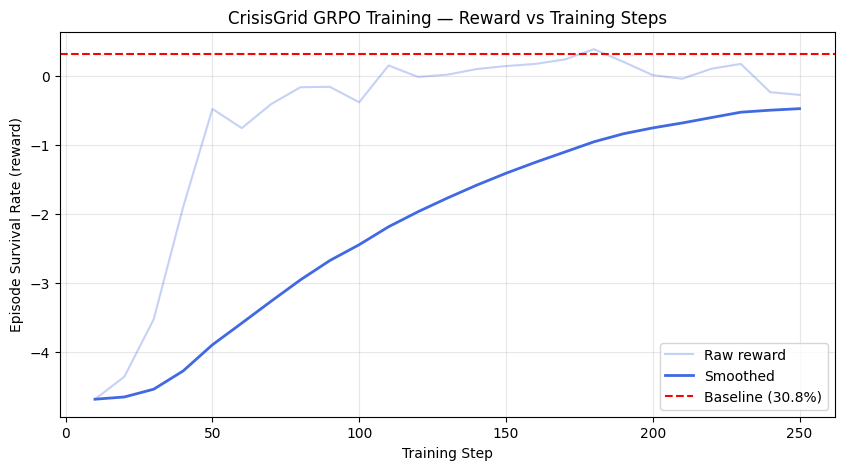

Curve saved to Drive


In [19]:
# CELL 13: Plot Training Curve
import matplotlib.pyplot as plt

history = trainer.state.log_history
steps, rewards = [], []
for entry in history:
    if 'reward' in entry:
        steps.append(entry['step'])
        rewards.append(entry['reward'])

def smooth(x, w=0.9):
    if not x: return []
    s = x[0]; out = []
    for v in x: s = s*w + v*(1-w); out.append(s)
    return out

plt.figure(figsize=(10, 5))
plt.plot(steps, rewards, alpha=0.3, color='royalblue', label='Raw reward')
if rewards: plt.plot(steps, smooth(rewards), color='royalblue', lw=2, label='Smoothed')
plt.axhline(BASELINE, color='red', ls='--', label=f'Baseline ({BASELINE:.1%})')
plt.title('CrisisGrid GRPO Training — Reward vs Training Steps')
plt.xlabel('Training Step')
plt.ylabel('Episode Survival Rate (reward)')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(f'{PROJECT_PATH}/crisisgrid_training_curve.png', dpi=200, bbox_inches='tight')
plt.show()
print('Curve saved to Drive')

In [23]:
# CELL 14: Generate A/B Demo Episodes
import json

def record_episode(agent_type, seed=123):
    env = CrisisGridEnv(seed=seed)
    obs, _ = env.reset()
    rng = np.random.RandomState(seed)
    done, step, traj = False, 0, []

    if agent_type == 'trained':
        grid = env.grid.copy()
        prompt = build_episode_prompt(grid)
        inputs = tokenizer(prompt, return_tensors='pt').to('cuda')
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=800, do_sample=False)
        resp = tokenizer.decode(out[0], skip_special_tokens=True)[len(prompt):].strip()
    try:
        text = resp
        if text.startswith("```"):
            text = text.split("```")[1]
            if text.startswith("json"):
                text = text[4:]
            text = text.strip()
        if text.startswith("[") and not text.endswith("]"):
            last_brace = text.rfind("}")
            if last_brace != -1:
                text = text[:last_brace + 1] + "]"
        actions = json.loads(text)
        if not isinstance(actions, list): actions = [actions]
    except:
        actions = []

    while not done and step < 50:
        if agent_type == 'trained':
            if step < len(actions):
                msg = decode_action(actions[step])
            else:
                msg = {'intent':'hold','zone':0,'resource':'food','priority':'low','units':1}
        else:
            msg = {'intent':'allocate','zone':int(rng.randint(0,25)),
                   'resource':rng.choice(['medicine','food','rescue']),
                   'priority':rng.choice(['high','medium','low']),
                   'units':int(rng.randint(1,6))}
        _, r, done, info = env.step(msg)
        traj.append({'step':step+1,'msg':msg,'reward':round(r,4),
                     'survival_rate':round(info['survival_rate'],4),
                     'mean_severity':round(info['mean_severity'],4)})
        step += 1

    return {'agent_type':agent_type,'final_survival':info.get('survival_rate', 0.0),'trajectory':traj}

ep_random  = record_episode('random')
ep_trained = record_episode('trained')

with open(f'{PROJECT_PATH}/data/demo_random.json',  'w') as f: json.dump(ep_random,  f, indent=2)
with open(f'{PROJECT_PATH}/data/demo_trained.json', 'w') as f: json.dump(ep_trained, f, indent=2)

print(f'Random agent survival:  {ep_random["final_survival"]:.1%}')
print(f'Trained agent survival: {ep_trained["final_survival"]:.1%}')
print('Demo episodes saved to Drive')

Both `max_new_tokens` (=800) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Random agent survival:  22.7%
Trained agent survival: 61.2%
Demo episodes saved to Drive


In [24]:
# CELL 15: Save Final Checkpoint to Drive
final_ckpt = f'{CKPT_DIR}/final'
model.save_pretrained(final_ckpt)
tokenizer.save_pretrained(final_ckpt)
print(f'Final model saved to: {final_ckpt}')

Final model saved to: /content/drive/MyDrive/crisisgrid_checkpoints/final
